In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets
import plotly.express as px

In [2]:
#Fetch data 
data_dir = './nilearn_data' # ajout de l'endroit pour télécharger data, plus facile à répliquer ensuite
data = datasets.fetch_adhd(n_subjects=40, data_dir = data_dir) # prend tout le dataset disponible contrairement à étude original

[fetch_adhd] Dataset found in nilearn_data/adhd


In [3]:
# Type de données dans notre data set
data.keys()

dict_keys(['func', 'confounds', 'phenotypic', 'description', 't_r'])

40

In [4]:
# Transformation de phenotypes en taableau
pheno = pd.DataFrame(data.phenotypic)

In [12]:
pheno_40 = pd.read_csv('nilearn_data/adhd/ADHD200_40subs_motion_parameters_and_phenotypics.csv')

In [10]:
pheno.head()

,Unnamed: 0,Subject,Rest.Scan,MeanFD,NumFD_greater_than_0.20,rootMeanSquareFD,FDquartile.top1.4thFD.,PercentFD_greater_than_0.20,MeanDVARS,MeanFD_Jenkinson,...,sess_1_rest_6_eyes,sess_1_anat_1,sess_1_which_anat,sess_2_rest_1,sess_2_rest_1_eyes,sess_2_rest_2,sess_2_rest_2_eyes,sess_2_anat_1,defacing_ok,defacing_notes
0,1,2014113,rest_1,0.0576,2,0.2400,0.0944,1.6,16.1677,1.3868,...,NaN,pass,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN
1,2,3902469,rest_1,0.0580,0,0.2409,0.0931,0.0,17.4188,1.2040,...,NaN,pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,4275075,rest_1,0.0789,0,0.2808,0.1520,0.0,17.7796,1.8105,...,NaN,pass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,7774305,rest_1,0.0679,0,0.2606,0.1054,0.0,16.7169,1.5137,...,NaN,pass,NaN,NaN,NaN,NaN,NaN,NaN,yes,defaced part of front skull/brain
4,5,1019436,rest_1,0.0904,0,0.3006,0.1927,0.0,19.6124,1.6769,...,NaN,pass,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN


In [5]:
# Tous les types de données phénotype possible
pheno.columns 

Index(['Unnamed: 0', 'Subject', 'Rest.Scan', 'MeanFD',
       'NumFD_greater_than_0.20', 'rootMeanSquareFD', 'FDquartile.top1.4thFD.',
       'PercentFD_greater_than_0.20', 'MeanDVARS', 'MeanFD_Jenkinson', 'site',
       'sibling_id', 'data_set', 'age', 'sex', 'handedness', 'full_2_iq',
       'full_4_iq', 'viq', 'piq', 'iq_measure', 'tdc', 'adhd',
       'adhd_inattentive', 'adhd_combined', 'adhd_subthreshold',
       'diagnosis_using_cdis', 'notes', 'sess_1_anat_2', 'oppositional',
       'cog_inatt', 'hyperac', 'anxious_shy', 'perfectionism',
       'social_problems', 'psychosomatic', 'conn_adhd', 'restless_impulsive',
       'emot_lability', 'conn_gi_tot', 'dsm_iv_inatt', 'dsm_iv_h_i',
       'dsm_iv_tot', 'study', 'sess_1_rest_1', 'sess_1_rest_1_eyes',
       'sess_1_rest_2', 'sess_1_rest_2_eyes', 'sess_1_rest_3',
       'sess_1_rest_3_eyes', 'sess_1_rest_4', 'sess_1_rest_4_eyes',
       'sess_1_rest_5', 'sess_1_rest_5_eyes', 'sess_1_rest_6',
       'sess_1_rest_6_eyes', 'sess_1_a

In [6]:
# Vérifier combien de participants ont des données phéno
len(pheno) 

30

<Axes: xlabel='adhd', ylabel='Count'>

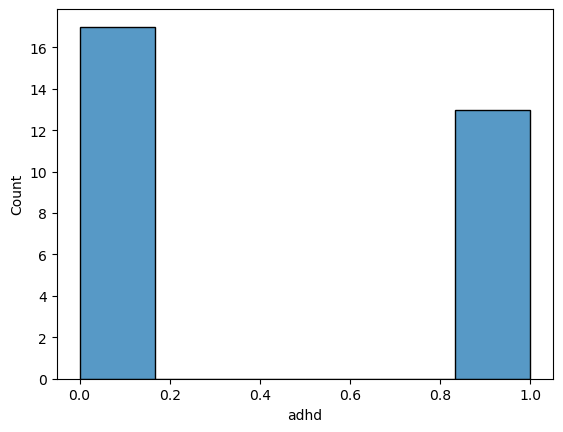

In [17]:
# Regarder la distribution des diagnostics de TDAH
sns.histplot(pheno['adhd']) # 0 = contrôle, 1 = adhd

<Axes: xlabel='adhd', ylabel='Count'>

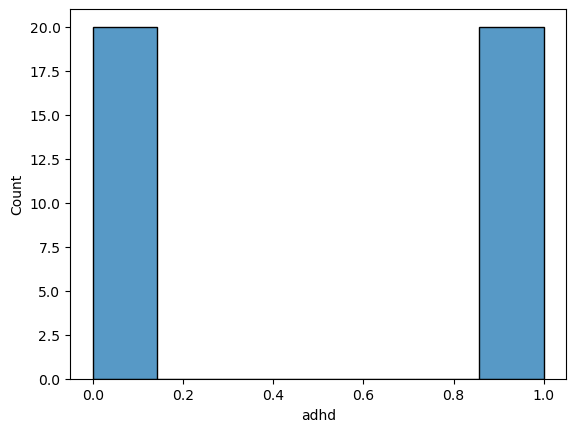

In [14]:
sns.histplot(pheno_40['adhd']) # 0 = contrôle, 1 = adhd

<Axes: xlabel='age', ylabel='Count'>

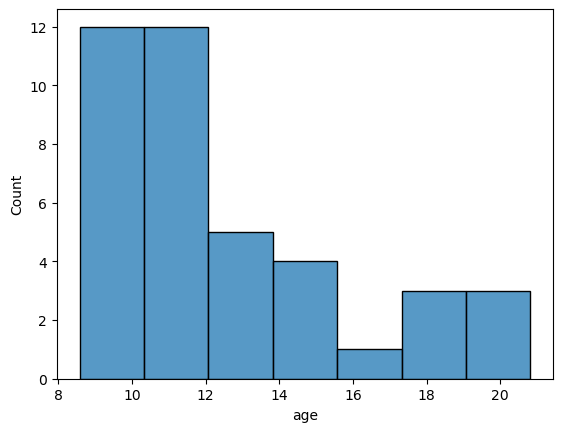

In [15]:
sns.histplot(pheno_40['age'])

In [38]:
# Vérification des sujets dans les dataframe pheno
sujet_40 = pheno_40['Subject']
sujet_30 = pheno['Subject']
sujet_nilearn = [
        "0010042",
        "0010064",
        "0010128",
        "0021019",
        "0023008",
        "0023012",
        "0027011",
        "0027018",
        #"0027034",
        "0027037",
        #"1019436",
        "1206380",
        "1418396",
        "1517058",
        "1552181",
        "1562298",
        "1679142",
        #"2014113",
        "2497695",
        "2950754",
        "3007585",
        #"3154996",
        "3205761",
        "3520880",
        "3624598",
        #"3699991",
        #"3884955",
        #"3902469",
        "3994098",
        "4016887",
        "4046678",
        "4134561",
        "4164316",
        #"4275075",
        "6115230",
        #"7774305",
        "8409791",
        "8697774",
        "9744150",
        "9750701",
    ]

In [46]:
sujet_40

0     2014113
1     3902469
2     4275075
3     7774305
4     1019436
5     3699991
6     3154996
7     3884955
8       27034
9     4134561
10      27018
11    6115230
12      27037
13    8409791
14      27011
15    3007585
16    8697774
17    9750701
18      10064
19      21019
20      10042
21      10128
22    2497695
23    4164316
24    1552181
25    4046678
26      23012
27    1679142
28    1206380
29      23008
30    4016887
31    1418396
32    2950754
33    3994098
34    3520880
35    1517058
36    9744150
37    1562298
38    3205761
39    3624598
Name: Subject, dtype: int64